# EDA -- Titanic dataset
*исходники --->* https://www.kaggle.com/competitions/titanic/data 

сеттим библиотеки

In [74]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


## A) Быстрый обзор данных (Pandas)

In [75]:
df = pd.read_csv("TitanicDataset/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [76]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [77]:
print( "table size --> ",df.shape)

table size -->  (891, 12)


In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [79]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [80]:
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [81]:
print("пропуски : \n" , df.isnull().sum())

пропуски : 
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [82]:
print("Количество дубликатов -->", df.duplicated().sum())

Количество дубликатов --> 0


## B) Пропуски и очистка

In [83]:
print("Средний возраст --> ", df['Age'].median())

Средний возраст -->  28.0


In [84]:
# сеттим средний возраст в пропущенные ячейки возраста
df['Age'] = df['Age'].fillna(df['Age'].median())

In [85]:
# сеттим моду в категориальную колонку Embarked с пропущенными значениями
print("Мода Embarked --> ", df['Embarked'].mode()[0])
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Мода Embarked -->  S


In [86]:
#удаляем колонку Cabin тк слишком много пропусков
df = df.drop('Cabin', axis=1)

In [87]:
# финальный чек 
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## C) Расширенная статистика

In [88]:
numCols = ['Pclass','Age','SibSp','Parch','Fare']

for col in numCols :
    print(f"\n{col}")
    print("min value--> ", df[col].min())
    print("max value--> ", df[col].max())
    print("mean value --> ", df[col].mean())
    print("median value --> ",df[col].median())
    print("mode value --> ", df[col].mode()[0])
    


Pclass
min value-->  1
max value-->  3
mean value -->  2.308641975308642
median value -->  3.0
mode value -->  3

Age
min value-->  0.42
max value-->  80.0
mean value -->  29.36158249158249
median value -->  28.0
mode value -->  28.0

SibSp
min value-->  0
max value-->  8
mean value -->  0.5230078563411896
median value -->  0.0
mode value -->  0

Parch
min value-->  0
max value-->  6
mean value -->  0.38159371492704824
median value -->  0.0
mode value -->  0

Fare
min value-->  0.0
max value-->  512.3292
mean value -->  32.204207968574636
median value -->  14.4542
mode value -->  8.05


In [89]:
#перцентели
q_list = [0.05,0.25,0.5,0.75,0.95]

print(df[numCols].quantile(q_list))

      Pclass   Age  SibSp  Parch       Fare
0.05     1.0   6.0    0.0    0.0    7.22500
0.25     2.0  22.0    0.0    0.0    7.91040
0.50     3.0  28.0    0.0    0.0   14.45420
0.75     3.0  35.0    1.0    0.0   31.00000
0.95     3.0  54.0    3.0    2.0  112.07915


In [90]:
for col in numCols:
    print(f"\n {col}")
    print("Дисперсия --> ", df[col].var())
    print("Ассиметрия --> ", df[col].skew())
    print("Эксцесс --> ", df[col].kurtosis())


 Pclass
Дисперсия -->  0.6990151199889028
Ассиметрия -->  -0.6305479068752845
Эксцесс -->  -1.2800149715782825

 Age
Дисперсия -->  169.51249827942345
Ассиметрия -->  0.5102446555756495
Эксцесс -->  0.9938710163801736

 SibSp
Дисперсия -->  1.2160430774662985
Ассиметрия -->  3.6953517271630565
Эксцесс -->  17.880419726645968

 Parch
Дисперсия -->  0.6497282437357343
Ассиметрия -->  2.7491170471010933
Эксцесс -->  9.778125179021648

 Fare
Дисперсия -->  2469.436845743116
Ассиметрия -->  4.787316519674893
Эксцесс -->  33.39814088089868


##  D) Фичи: Энкодинг и Инжиниринг (Feature Engineering)

In [91]:
# создаем копию исходного фрейма
df_enc = df.copy()
print("Фрейм до экнодинга: ", df_enc.shape)

Фрейм до экнодинга:  (891, 11)


In [92]:
# инжиринг по титулам
df_enc["Title"] = df["Name"].str.extract(' ([A-Za-z]+)\.',expand=False)

# чистим редкие титулы заменой на Rare
df_enc["Title"] = df_enc["Title"].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

# замена совпадений и аналогов
df_enc["Title"] = df_enc["Title"].replace(['Mlle', 'Ms'], 'Miss')
df_enc["Title"] = df_enc["Title"].replace('Mme', 'Mrs')

In [93]:
#формируем категориальные колонки по которым будет делать энкодинг
cat_cols = ["Sex","Embarked","Title"]
df_onehot = pd.get_dummies(df_enc, columns=cat_cols,drop_first=True)
df_onehot.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True,False,True,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True,True,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True,False,True,False,False


In [94]:


# хеш функция, просто как пример, датасет слишком маленький, ticket проще выкинуть либо сделать инжирирнг
def simple_hash(text, n_features=5):
    return hash(text) % n_features

df_onehot['name_hash'] = df_onehot['Name'].apply(lambda x: simple_hash(x))
df_onehot[['Name', 'name_hash']].head()

,Name,name_hash
0,"Braund, Mr. Owen Harris",4
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2
2,"Heikkinen, Miss. Laina",1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2
4,"Allen, Mr. William Henry",1


In [95]:
# генерация новых фич
df_onehot["Age_range"] = pd.cut(df_onehot["Age"],bins=[0, 12, 18, 35, 60, 100],labels=['child', 'teen', 'adult', 'middle', 'senior'])

age_map = {"child":0, "teen": 1, "adult": 2, "middle": 3, "senior": 4}
df_onehot["Age_code"] = df_onehot["Age_range"].map(age_map)

df_onehot["FamilySize"] = df_onehot["SibSp"] + df_onehot["Parch"] + 1

df_onehot["IsAlone"] = (df_onehot["FamilySize"] == 1).astype(int)

df_onehot["GroupSize"] = df_onehot.groupby('Ticket')["Ticket"].transform('count')

df_onehot["FarePerPerson"] = df_onehot["Fare"] / df_onehot["GroupSize"]


df_onehot.shape
df_onehot[["Age_range", "Age_code", "FamilySize", "IsAlone", "GroupSize", "FarePerPerson"]].head()

,Age_range,Age_code,FamilySize,IsAlone,GroupSize,FarePerPerson
0,adult,2,2,0,1,7.2500
1,middle,3,2,0,1,71.2833
2,adult,2,1,1,1,7.9250
3,adult,2,2,0,2,26.5500
4,adult,2,1,1,1,8.0500


# E) Визуализация 

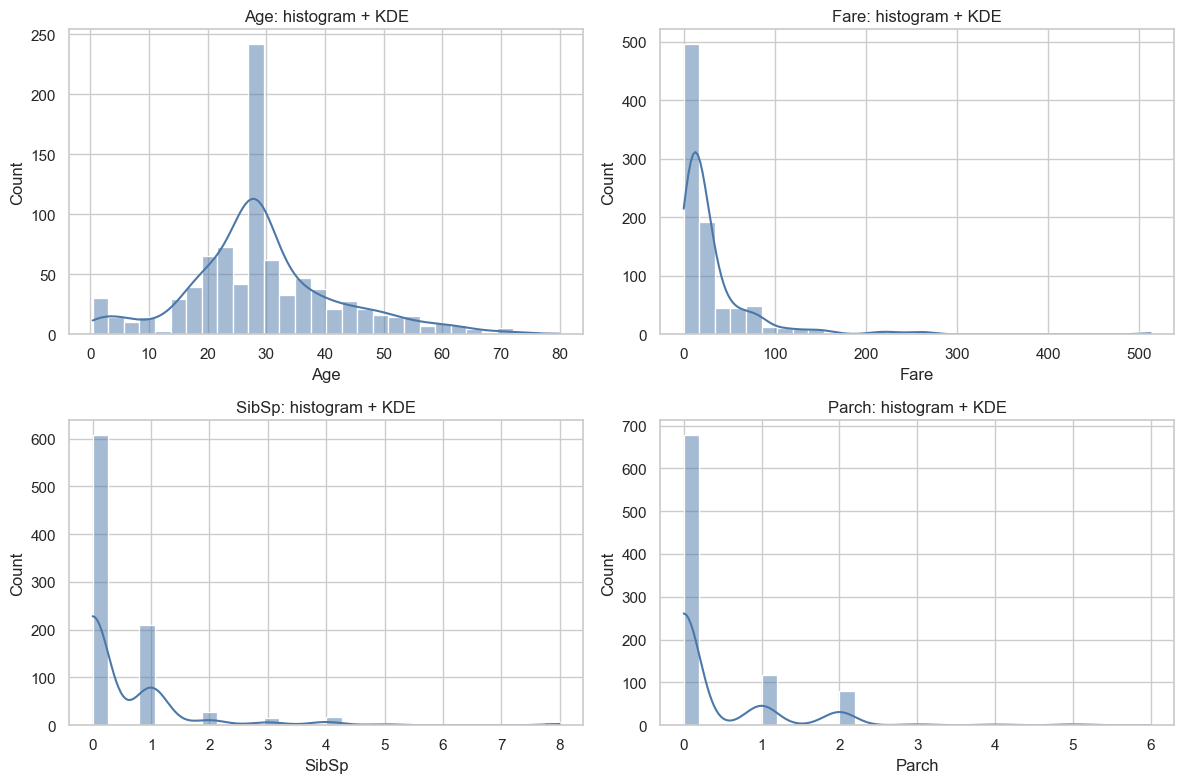

In [96]:
# Гистограмма и KDE (kernel density estimation --> оценка плотности ядра)

# сеттим тему
sns.set_theme(style="whitegrid")

# колонки для которых будем строить гистограммы и KDE
dist_cols = ["Age", "Fare", "SibSp", "Parch"]

# создаем сет из 4 графиков (2 строки, 2 столбца)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# выравниваем массив осей для удобства итерации
axes = axes.flatten()

#enumerate для получения индекса и названия колонки, в виде кортежа (i, col)
for i, col in enumerate(dist_cols):
    # data=df - наш датафрейм, x=col - колонка по которой строим гистограмму, kde=True - добавляем KDE, bins=30 - количество бинов, ax=axes[i] - ось для текущего графика
    sns.histplot(data=df, x=col, kde=True, bins=30, ax=axes[i], color="#4C78A8")
    axes[i].set_title(f"{col}: histogram + KDE")

# подгоняем макет чтобы графики не налезали друг на друга
plt.tight_layout()
# отображаем графики
plt.show()


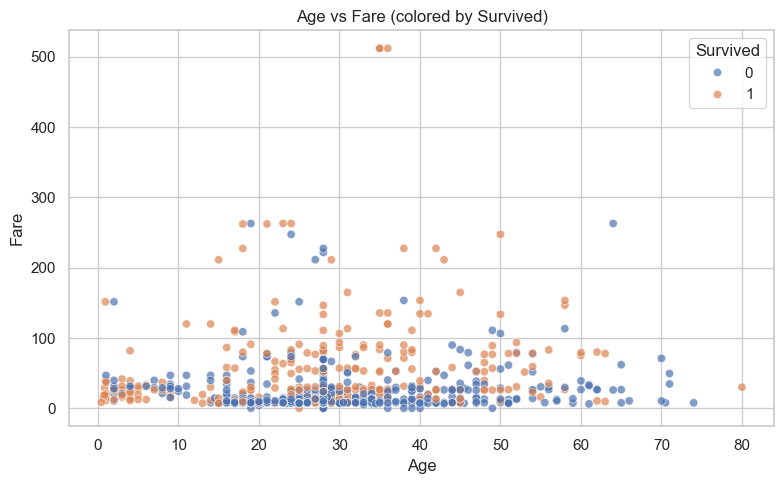

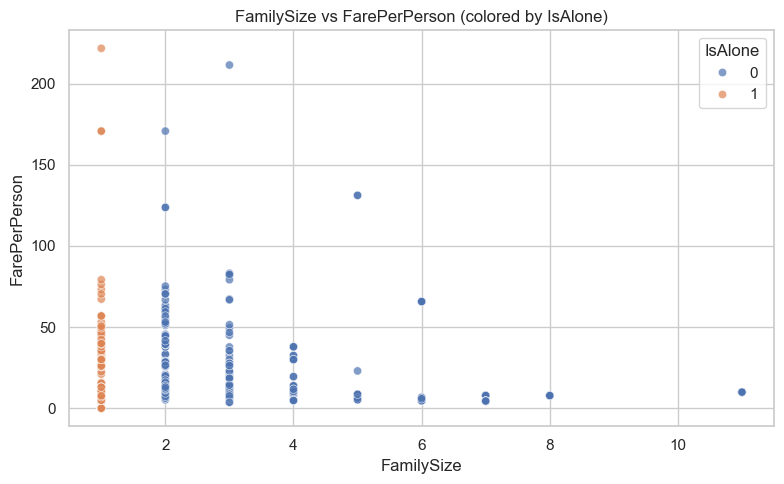

In [97]:
# scatter plot(диаграмма рассеяния)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived", alpha=0.7)
plt.title("Age vs Fare (colored by Survived)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_onehot, x="FamilySize", y="FarePerPerson", hue="IsAlone", alpha=0.7)
plt.title("FamilySize vs FarePerPerson (colored by IsAlone)")
plt.tight_layout()
plt.show()

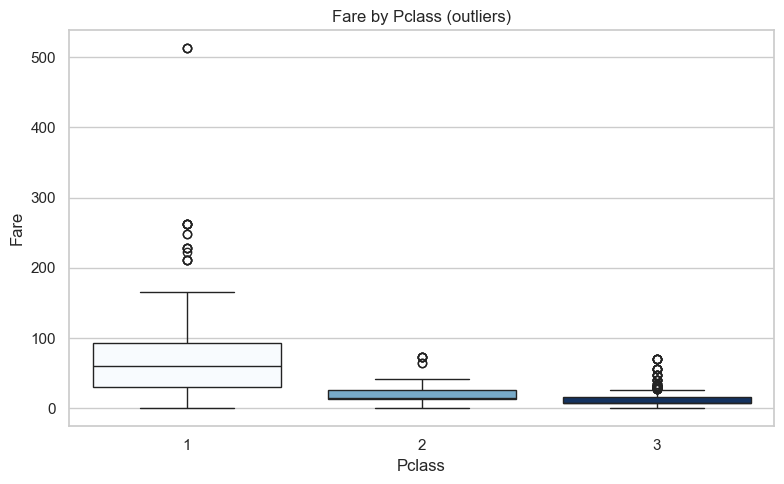

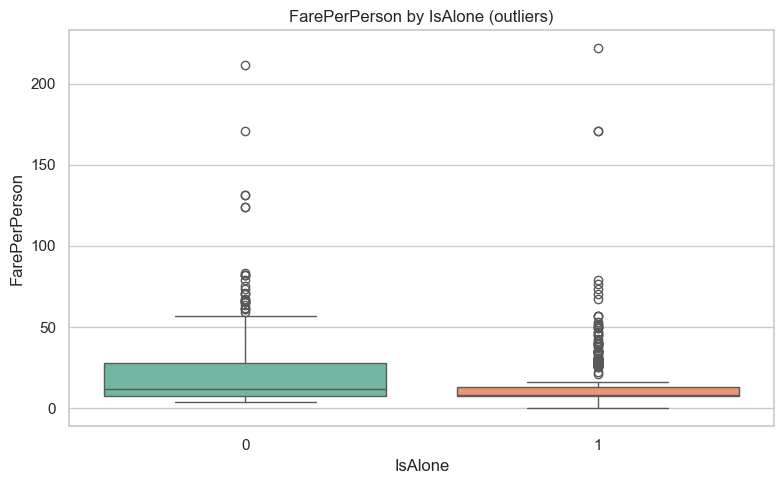

In [98]:
# Boxplot (ящик с усами)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Pclass", y="Fare", hue="Pclass", dodge=False, palette="Blues")
plt.title("Fare by Pclass (outliers)")
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.boxplot(data=df_onehot, x="IsAlone", y="FarePerPerson", hue="IsAlone", dodge=False, palette="Set2")
plt.title("FarePerPerson by IsAlone (outliers)")
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()

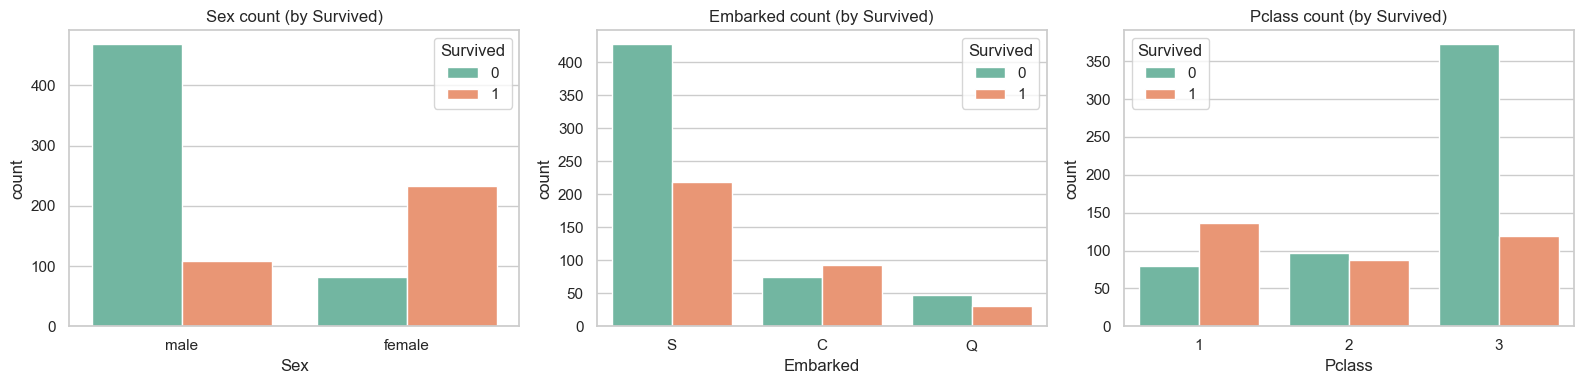

In [99]:
# Countplot (столбчатая диаграмма) для категориальных признаков

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df, x="Sex", hue="Survived", ax=axes[0], palette="Set2")
axes[0].set_title("Sex count (by Survived)")

sns.countplot(data=df, x="Embarked", hue="Survived", ax=axes[1], palette="Set2")
axes[1].set_title("Embarked count (by Survived)")

sns.countplot(data=df, x="Pclass", hue="Survived", ax=axes[2], palette="Set2")
axes[2].set_title("Pclass count (by Survived)")

plt.tight_layout()
plt.show()


In [ ]:
# Heatmap correlations (fixed stable version)
corr_cols = ['Survived', 'Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Sex_male', 'Embarked_Q', 'Embarked_S']
corr_matrix = df_onehot[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('Conclusions:')
print('- Sex_male has a negative correlation with Survived (women survived more often).')
print('- Pclass has a negative correlation with Survived (higher class survived more often).')
print('- Fare has a positive correlation with Survived (higher fare, higher survival rate).')
